[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zeiss/pylibczirw/blob/main/doc/jupyter_notebooks/pylibCZIrw_4_1_0.ipynb)


In [1]:
# Install pylibCZIrw and dependencies
#! pip install --upgrade pip
#! pip install "pylibCZIrw~=4.1" "cztile>=0.0,<1.0" matplotlib tqdm pooch

## pylibCZIrw - Tutorial

In this notebook one can see how to read and write CZI (Carl Zeiss Image) files using from Python using **[pylibCZIrw](https://pypi.org/project/pylibczirw/)**. This package is wrapper for the **libCZIrw** (C++) library and can be used both in Windows and Linux.

### Remarks

* At the moment, [pylibCZIrw](https://pypi.org/project/pylibczirw/) completely abstracts away the subblock concept, both in the reading and in the writing APIs.
* If [pylibCZIrw](https://pypi.org/project/pylibczirw/) is extended in the future to support subblock-based access (e.g. accessing acquisition tiles), this API must not be altered.

### Disclaimer

This notebook is free to use for everybody. Carl Zeiss Microscopy GmbH's ZEN software undertakes no warranty concerning the use of those scripts, image analysis settings and ZEN experiments. Use them on your own risk.

Additionally Carl Zeiss Microscopy GmbH's ZEN software allows connection and usage to the third party software packages.
Therefore Carl Zeiss Microscopy GmbH undertakes no warranty concerning those software packages, makes no representation that they will work on your system and/or hardware and will not be liable for any damages caused by the use of this extension. **By using any of those examples you agree to this disclaimer.**

Version: 2024.01.22

Copyright (c) 2024 Carl Zeiss AG, Germany. All Rights Reserved.

### Required Module Imports

Both reading and writing APIs are contained within the **czi** object in pylibCZIrw, so let's start by importing it.

Additional modules are imported alongside the **pylibCZIrw** package.

In [2]:
from pylibCZIrw import czi as pyczi
import json
import timeit
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os, sys
from tqdm import tqdm
from tqdm.contrib import itertools as it
from matplotlib.patches import Rectangle
from IPython.display import display, JSON

# show the used python env
print("Using:", sys.executable)

Using: /home/boudlal.h/.conda/envs/mimosa_dev/bin/python


/home/boudlal.h/.conda/envs/mimosa_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define parameters for data loading

In [3]:
# Define CZI locations


czifile_scenes = "/envau/work/invibe/USERS/IBOS/data/Marmoset/lames/1-renamed/5-Sully-MIO21100401/originaux/MIO21100401_Cx_104_112_120_128.czi"

### Opening a CZI (read-only)

A CZI file can be opened from disk in a context manager or alternatively it can also be opened directly from a seekable http url.

* `pyczi.ReaderFileInputTypes.Curl` reads from http
* * `pyczi.ReaderFileInputTypes.Standard` reads from file directly (default)

```python
from pylibCZIrw import pyczi

with czi.open_czi(file_path) as czi:

    # add your code here

with czi.open_czi(file_url, pyczi.ReaderFileInputTypes.Curl) as czi:

    # add your code here
```

Remark: Inside this notebook only the option to read from http is used which removes the need to download the data when using Colab notebooks.

### Open a CZI and read metadata

We can open a czi using a context manager and then read the full metadata either as a raw XML string or as a dictionary

In [4]:
# open the CZI for reading
with pyczi.open_czi(czifile_scenes) as czidoc:    # get the raw metadata as a dictionary
    md_dict = czidoc.metadata

    # show some parts of it
    # print(json.dumps(md_dict["ImageDocument"]["Metadata"]["Information"]["Image"], sort_keys=False, indent=4))
    display(JSON(md_dict["ImageDocument"]["Metadata"]["Information"]["Image"], expanded=False))

<IPython.core.display.JSON object>

## Get Image dimensions
There are different properties that allow us to retrieve information about dimensions.
The **`total_bounding_box`** gives us all the dimensions of all **orthogonal planes** of the CZI image file.

The **`total_bounding_rectangle`** gives us the X and Y dimensions of the CZI, i.e. the (X, Y) of the **`total_bounding_box`**.

In [5]:
with pyczi.open_czi(czifile_scenes) as czidoc:    # get the total bounding box for all scenes
    total_bounding_rectangle = czidoc.total_bounding_rectangle

print(total_bounding_rectangle)

Rectangle(x=-156427, y=4590, w=121376, h=58508)


**Scenes are not orthogonal to the other dimensions.**
They are contained within the 2D planes and can be seen simply as tags for certain regions.

The **`scene_bounding_rectangle`** give us the bounding rectangle for each scene.

## Get the pixel type
A channel's pixel type can be discovered with using: **`get_channel_pixel_type`**

In [6]:
with pyczi.open_czi(czifile_scenes) as czidoc:    # get the pixel type for the 1st channel
    c0_pixel_type = czidoc.get_channel_pixel_type(0)

print(c0_pixel_type)

Gray16


Or we can simply get all pixel types using: **`pixel_types`**

In [7]:
with pyczi.open_czi(czifile_scenes) as czidoc:    # get all pixel types as a dictionary, where the key is the channel index
    pixel_type = czidoc.pixel_types

print(pixel_type)

{0: 'Gray16', 1: 'Gray16'}


## Read pixel data
Pixel data is read and returned as a numpy arry. The shape of the returned array and its data type will depend on the specified `pixel_type`.
- BGR pixel type -> [y, x, 3]
- Gray pixel type -> [y, x, 1]

The background_pixel determines the pixel value for the background (i.e. regions where no pixel data exists),
 and must be consistent with the `pixel_type`

|pixel_type | background_pixel type | Default value  | 
--- | --- | ---
|BGR|3-value tuple |(0, 0, 0)|
|Gray|Scalar value bounded by the gray scale|0|

### Read whole 2D plane

In order to **`read`** pixel data from a CZI image file it is important to understand the concept of "planewise reading".

Reading data planewise means that every read operation yields a 2D array with the shape (Y, X, 1) or (Y, X, 3) depending on the requested pixel type.
We can specify which 2D plane to read using the **`plane`** argument (dictionary).

* **`plane = {'C': 0, 'Z': 2, 'T': 1}`** - this will read a 2D plane from C=0, Z=2 and T=1
* if **`plane`** is not specified at all the default is to use the 1st index for all dimensions

In order to read a complete Z-Stack, one would have to read each of the Z-slices using the plane argument. This can be easily created by "wrapping" those calls into some utility functions.
To get started let's read a complete 2D plane.

### Read ROI inside a specific 2D plane

We can also read an ROI within the 2D plane by using the **`roi`** argument.
This is particularly useful when dealing with large images whose planes would not fit into memory.

The **`roi`** is a tuple defined as a (axis-aligned) rectangle in **(x, y, w, h)** form, with:

* x = x coordinate of upper-left point
* y = y coordinate of upper-left point
* w = rectangle width
* h = rectangle height

Text(0.5, 1.0, 'ch1')

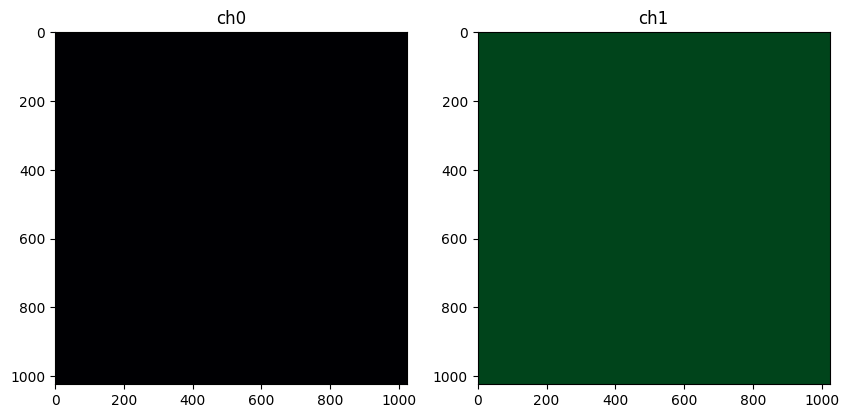

In [8]:
# define the ROI using upper left, widht and height as coordinates
my_roi = (-50000, 1825, 1024, 1024)
#-77155, y=1825, w=67859, h=31570

with pyczi.open_czi(czifile_scenes) as czidoc:
    ch0 = czidoc.read(roi=my_roi, plane={'C': 0})
    ch1 = czidoc.read(roi=my_roi, plane={'C': 1})

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ch0[..., 0], cmap=cm.inferno, vmin=100, vmax=2000)
ax[0].set_title("ch0")
ax[1].imshow(ch1[..., 0], cmap=cm.Greens_r, vmin=100, vmax=500)
ax[1].set_title("ch1")

### Read ROI only for one scene
We can also get pixel data exclusively from one scene using the **`scene`** argument. This argument acts as
a filter returning only data from the specified scene. If not set, data from all scenes is returned.

We can also specify a **`zoom`** factor between 0 and 1. This can be very useful to read images at a lower resolution,
because not every application requires the full resolution.

In [9]:
#! pip install --upgrade pip
#! pip install --upgrade nibabel
#import  as nib


ROI  affichage (-130763, 17224, 4096, 4096)
factor 256  ROI (16, 16)  scene (102, 216)
factor   4  ROI (1024, 1024)  scene (6583, 13856)


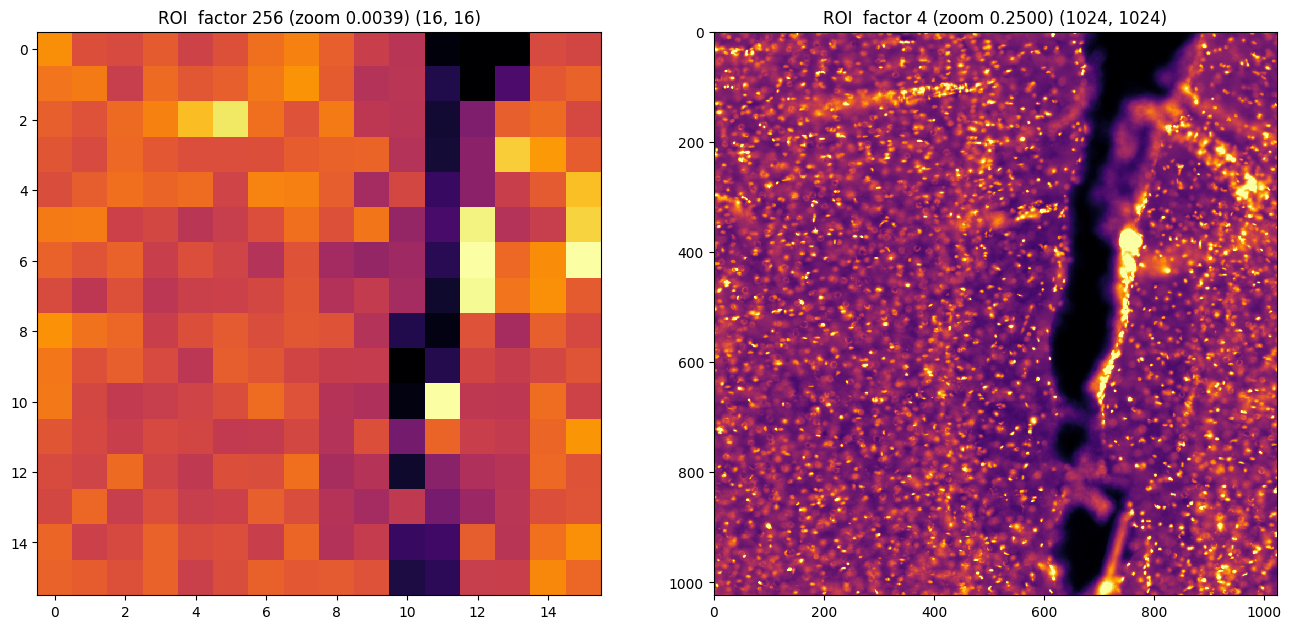

saved ds256_C0.nii.gz
saved ds4_C0.nii.gz


In [10]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Deux facteurs de downsampling, en puissances de 2 ---
factor_1 = 2 ** 8   # = 16  -> zoom = 1/16
factor_2 = 2 ** 2     # = 4   -> zoom = 1/4
zl1 = 1.0 / factor_1
zl2 = 1.0 / factor_2

channel = 0
scene   = 0

# taille de la ROI (pixels natifs) juste pour l'AFFICHAGE
roi_size = 4096
offset_x = 0
offset_y = 0

with pyczi.open_czi(czifile_scenes) as czidoc:
    rect = czidoc.scenes_bounding_rectangle[scene]      # (x, y, w, h) de la scène

    # --- ROI centrée, pour l'affichage ---
    x0 = rect[0] + (rect[2] - roi_size) // 2 + offset_x
    y0 = rect[1] + (rect[3] - roi_size) // 2 + offset_y
    roi = (x0, y0, roi_size, roi_size)
    z1_roi = czidoc.read(plane={'C': channel}, roi=roi, scene=scene, zoom=zl1)[..., 0]
    z2_roi = czidoc.read(plane={'C': channel}, roi=roi, scene=scene, zoom=zl2)[..., 0]

    # --- Scène entière, pour la sauvegarde ---
    full = (rect[0], rect[1], rect[2], rect[3])
    z1_full = czidoc.read(plane={'C': channel}, roi=full, scene=scene, zoom=zl1)[..., 0]
    z2_full = czidoc.read(plane={'C': channel}, roi=full, scene=scene, zoom=zl2)[..., 0]

print(f"ROI  affichage {roi}")
print(f"factor {factor_1:>3}  ROI {z1_roi.shape}  scene {z1_full.shape}")
print(f"factor {factor_2:>3}  ROI {z2_roi.shape}  scene {z2_full.shape}")

# --- AFFICHAGE de la ROI (nearest pour voir les pixels) ---
v1 = np.percentile(z1_roi, [1, 99])
v2 = np.percentile(z2_roi, [1, 99])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(z1_roi, cmap=cm.inferno, vmin=v1[0], vmax=v1[1], interpolation="nearest")
ax[0].set_title(f"ROI  factor {factor_1} (zoom {zl1:.4f}) {z1_roi.shape}")
ax[1].imshow(z2_roi, cmap=cm.inferno, vmin=v2[0], vmax=v2[1], interpolation="nearest")
ax[1].set_title(f"ROI  factor {factor_2} (zoom {zl2:.4f}) {z2_roi.shape}")
plt.show()

# --- SAUVEGARDE de la SCÈNE ENTIÈRE ---
for z, factor in ((z1_full, factor_1), (z2_full, factor_2)):
    new_affine = np.diag([factor, factor, 1, 1]).astype(float)
    img = nib.Nifti1Image(np.swapaxes(z, 0, 1), new_affine)
    nib.save(img, f"ds{factor}_C0.nii.gz")
    print(f"saved ds{factor}_C0.nii.gz")

## Writing a CZI file

* **The writing API only allows creating new CZI files.**
* editing existing czi file is not supported.
* writing API is follows the same principles as the reading API.

### Create a new CZI

Similarly to reading, before writing, we must create a CZI instance.
Ideally this is done using a context manager again.

### Write pixel data

Writing pixel data is very similar to reading albeit with fewer arguments:

* the **`plane`** to which the pixel data should be written.
* the data to be written, as a numpy array.

The pixel type in which the data is written is automatically determined from the shape and data type of the provided array.

In order to create a new CZI file we must provide the file name.
The optional flag (**`exist_ok`**) allows overwriting if set to **`True`** (default is **`False`**).

We can also write data to a specific **`location`** within the plane by providing the upper left pixel coordinates.

To illustrate this idea let's write all z-planes from the image "side-by-side" into a new CZI image.

![newCZI_stack.czi - shown in ZEN blue](screenshots/new_czi_stack.png)

### Write scenes

Writing a scene is in fact "just" writing pixel data to a specific region within a plane and tagging it with a **`scene`** index.
To illustrate this we now will write the z-planes to different scenes at different locations.

![new_czi_scenes - shown in ZEN blue](screenshots/new_czi_scenes.png)

### ZSTD Compression

#### Why we have used ZSTD Compression?
It is a fast compression technique, which provides the high compression ratios. We are handling these three modes:

1. uncompressed: - Default setting, the image would not be compressed.
2. zstd0 - You can specify the parameters of it like "explicitlevel" between -131072 and 22. <b>(e.g. "zstd0:ExplicitLevel=10")</b>
3. zstd1 - You can specify the parameters of it like "explicitlevel" between -131072 and 22 or "preprocess" - only have HiLoByteUnpack. This is only done for zstd1 and for pixel types gray16 and Bgr48. <b>(e.g. "zstd1:ExplicitLevel=10" or "zstd1:Preprocess=HiLoByteUnpack")</b>

To read more: https://facebook.github.io/zstd/

### Write Metadata

**Metadata is automatically written**, however, we can write some additional metadata by explicitly calling
 **`write_metadata`** with the following **optional** parameters:

- **`document_name`** (in ZEN: "Title")
- **`channel_names`** (in ZEN: "Channel Names")
- **`custom_attributes`** (Not visible in ZEN)
- **`scale_x`**, **`scale_y`**, **`scale_z`** in **meters (!)** (in ZEN: "Scaling (per Pixel)")

The parameter **`custom_attributes`** allows customized attributes with type int, float, boolean or string. If an attribute already exists, writing the same attribute again will replace the existing value.

This list of parameters will be extended on a case-by-case basis in the future.

***

![new_czi_z=32_metadata - shown in ZEN blue](screenshots/new_czi_z32_metadata.png)

## Subblock caching

In certain scenarios (e.g. reading from a stream or reading compressed images) caching uncompressed subblocks might yield a higher reading performance. A CZI reader allows for specifying caching options that lead to subblocks being cached after their first use.

## Tiling a large image

The read and write API allow the user to work with large images by allowing breaking down the access using the **`roi`** argument.
However, defining these rois (aka tiles) can be a cumbersome process.

The **czitile** package was created to answer this need.

**The package contains pure logic for tiling a rectangle. This means it is not file or format bound in any way.**

Let's read the original file using cztile and write a new with the same dimensions and scenes but with
random data instead.

### Define a 2D processing function

The benefits of tiling are evident when the data needs to be broken down for processing.
Segmentation using Deep Neural Networks is a great example of a task where images must be cut to fit.
We can use **czitile** to break down the image into tiles with some overlap.

We can illustrate this with a simpler 2D processing function first.

### Opening a CZI file for reading and write to a new CZI in parallel

The idea of tile-wise processing can enable the following approach:

* open the "original CZI image file for reading
* tile the image using **czitile**
* use the computed tiles as the **roi** parameters to read a "tile" of data
* apply the desired processing to the read tile
* write the processed tile into the new CZI at the correct location using the tile properties